# SAC training metrics

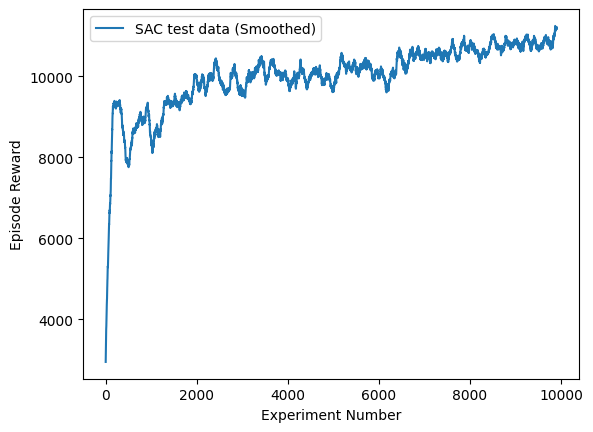

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def moving_average(data, window_size=5):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

experiment_name = 'sac_c10+n-10_b100'

eval_data_path = os.path.join('experiments', experiment_name, 'training_data.csv')

df = pd.read_csv(eval_data_path)
rewards = []
experiment_numbers = []
index_value = df.index[df['timestep'] == 0].tolist()

for i in range(len(index_value)):
    if i != len(index_value) - 1:
        start_index = index_value[i]
        end_index = index_value[i + 1] - 1

        subset_df = df.loc[start_index:end_index, ['reward', 'experiment_number']]
        reward_sum = subset_df['reward'].sum()
        rewards.append(reward_sum)
        experiment_number = subset_df['experiment_number'].iloc[0]
        experiment_numbers.append(experiment_number)

# Apply moving average smoothing only to rewards
smoothed_rewards = moving_average(rewards, window_size=100)

# Adjust max reward index for the smoothed values
max_reward_index = np.argmax(smoothed_rewards)

#plt.scatter(experiment_numbers[max_reward_index], smoothed_rewards[max_reward_index], color='blue', marker='o', s=50, zorder=3)
plt.plot(experiment_numbers[:len(smoothed_rewards)], smoothed_rewards, label='SAC test data (Smoothed)')
plt.xlabel("Experiment Number")
plt.ylabel("Episode Reward")
plt.legend()
plt.show()


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

def moving_average(data, window_size=5):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

experiment_name = 'sac_c10+n-10_b100'
eval_data_path = os.path.join('experiments', experiment_name, 'training_data.csv')

df = pd.read_csv(eval_data_path)
rewards = []
experiment_numbers = []
index_value = df.index[df['timestep'] == 0].tolist()

for i in range(len(index_value)):
    if i != len(index_value) - 1:
        start_index = index_value[i]
        end_index = index_value[i + 1] - 1

        subset_df = df.loc[start_index:end_index, ['reward', 'experiment_number']]
        reward_sum = subset_df['reward'].sum()
        rewards.append(reward_sum)
        experiment_number = subset_df['experiment_number'].iloc[0]
        experiment_numbers.append(experiment_number)

# Apply moving average smoothing
smoothed_rewards = moving_average(rewards, window_size=100)



In [3]:
ten_percent_values = int((len(smoothed_rewards) * 0.20))
last_n_rewards = smoothed_rewards[-ten_percent_values:]


average_last_n_rewards = sum(last_n_rewards)/len(last_n_rewards)

first_1000_reward = smoothed_rewards[:1000]  # Select first 1000 rewards
max_reward_1000 = np.max(first_1000_reward)  # Find max reward
epi_number_1000 = np.argmax(first_1000_reward)  # Find index of max reward
print(epi_number_1000)
max_reward = max(smoothed_rewards)

last_n_percentage = (average_last_n_rewards / max_reward) * 100

last_n_percentage
average_last_n_rewards

306


np.float64(10771.135909090928)

In [5]:
start_peak_reward = 9393.3
start_peak_ep_num = 190

first_peaks = first_1000_reward[start_peak_ep_num:epi_number_1000]
        
average_peak = first_peaks.sum()/len(first_peaks)
average_peak

np.float64(9312.117241379312)

# Check what percentage of max average value is the peak in first 1000 rewards

In [6]:
percentage_1000 =  (start_peak_reward/average_last_n_rewards) * 100

percentage_1000

np.float64(87.20807238233785)

# Determine when it hits 95%

2380.0 10256.2


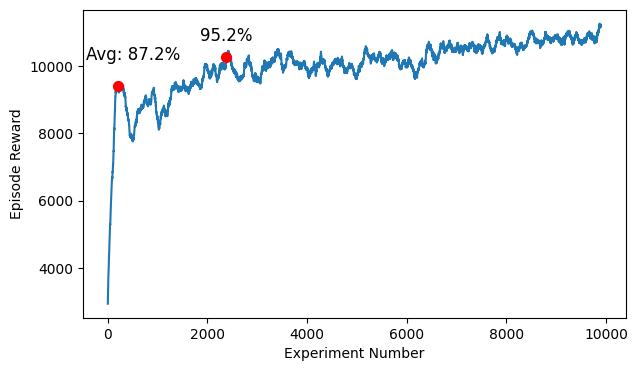

In [ ]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Find peaks (local maxima)
peak_indices, _ = find_peaks(smoothed_rewards, prominence=10)  # Adjust prominence if needed

percentage = 0
for peak in peak_indices:
    if peak > 1000 and peak < len(smoothed_rewards) - ten_percent_values:
        peak_reward = smoothed_rewards[peak]
        episode_number = experiment_numbers[peak]
        percentage = (peak_reward / average_last_n_rewards) * 100

    if percentage > 95:
        break


print(episode_number, peak_reward)
# Define scatter points
scatter_points_x = [200, episode_number]
scatter_points_y = [9393.3, peak_reward]

plt.figure(figsize=(7,4))
# Plot the smoothed rewards curve
plt.plot(experiment_numbers[:len(smoothed_rewards)], smoothed_rewards, label="Smoothed Rewards")

# Scatter plot for local maxima
plt.scatter(scatter_points_x, scatter_points_y, color='red', zorder=4, s=50)

# Add text annotations
plt.text(scatter_points_x[0] + 300, scatter_points_y[0] + 800, f'Avg: {round(percentage_1000,1)}%', fontsize=12, color='black', ha='center', zorder=4)
plt.text(scatter_points_x[1], scatter_points_y[1] + 500, f"{round(percentage,1)}%", fontsize=12, color='black', ha='center', zorder=4)

# Labels and legend
plt.xlabel("Experiment Number")
plt.ylabel("Episode Reward")
plt.show()


# PPO

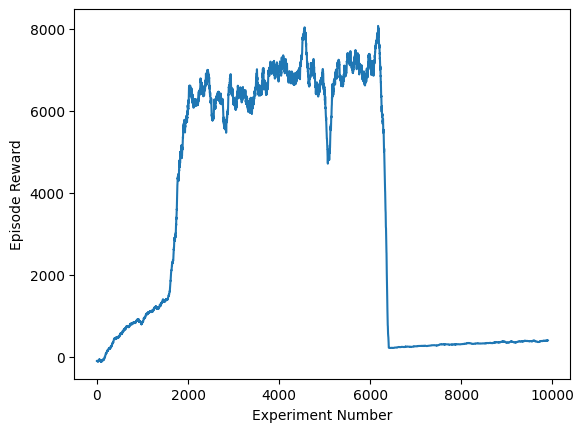

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def moving_average(data, window_size=5):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

ppo_experiment_name = 'ppo_c10+n-10_b100'

ppo_eval_data_path = os.path.join('experiments', ppo_experiment_name, 'training_data.csv')

df = pd.read_csv(ppo_eval_data_path)
rewards = []
experiment_numbers = []
index_value = df.index[df['timestep'] == 0].tolist()

for i in range(len(index_value)):
    if i != len(index_value) - 1:
        start_index = index_value[i]
        end_index = index_value[i + 1] - 1

        subset_df = df.loc[start_index:end_index, ['reward', 'experiment_number']]
        reward_sum = subset_df['reward'].sum()
        rewards.append(reward_sum)
        experiment_number = subset_df['experiment_number'].iloc[0]
        experiment_numbers.append(experiment_number)

# Apply moving average smoothing only to rewards
smoothed_rewards = moving_average(rewards, window_size=100)

# Adjust max reward index for the smoothed values
max_reward_index = np.argmax(smoothed_rewards)

#plt.scatter(experiment_numbers[max_reward_index], smoothed_rewards[max_reward_index], color='blue', marker='o', s=50, zorder=3)
plt.plot(experiment_numbers[:len(smoothed_rewards)], smoothed_rewards, label='SAC test data (Smoothed)')
plt.xlabel("Experiment Number")
plt.ylabel("Episode Reward")
plt.show()


In [9]:
max_ppo_reward = max(list(smoothed_rewards[1500:2000]))


per = (max_ppo_reward/average_last_n_rewards) * 100
print(experiment_numbers[list(smoothed_rewards).index(max_ppo_reward)])
print(per)

1999.0
57.08311594890021
